**Load recordings**

In [1]:
import numpy as np
from pathlib import Path
import re

# ============================================================
# Function 1: Get session paths
# ============================================================
def get_session_paths(base_dir):
    """
    Find all suite2p plane0 paths within a chronic imaging directory.
    For each Day folder, picks the first TSeries folder (ascending order)
    that contains suite2p/plane0.
    
    Parameters
    ----------
    base_dir : str or Path
        Path to the chronic imaging folder (e.g., JSY052_ChronicImaging)
    
    Returns
    -------
    session_paths : list of Path
        Sorted list of plane0 directories
    day_labels : list of str
        Corresponding day labels (e.g., ['Day1', 'Day2', ...])
    """
    base_dir = Path(base_dir)
    
    day_folders = [f for f in base_dir.iterdir() if f.is_dir() and 'Day' in f.name]
    
    def get_day_number(folder):
        match = re.search(r'Day(\d+)', folder.name)
        return int(match.group(1)) if match else 999
    
    day_folders = sorted(day_folders, key=get_day_number)
    
    session_paths = []
    day_labels = []
    
    for day_folder in day_folders:
        tseries_folders = list(day_folder.glob('TSeries-*'))
        
        if len(tseries_folders) == 0:
            print(f"WARNING: No TSeries folders found in {day_folder.name}, skipping")
            continue
        
        def get_tseries_number(folder):
            match = re.search(r'-(\d+)$', folder.name)
            return int(match.group(1)) if match else 999
        
        tseries_folders = sorted(tseries_folders, key=get_tseries_number)
        
        found = False
        for tseries in tseries_folders:
            plane0_path = tseries / 'suite2p' / 'plane0'
            if plane0_path.exists():
                session_paths.append(plane0_path)
                day_labels.append(f"Day{get_day_number(day_folder)}")
                print(f"Found: {day_folder.name} -> {tseries.name}")
                found = True
                break
        
        if not found:
            print(f"WARNING: No suite2p/plane0 found in any TSeries in {day_folder.name}")
    
    print(f"\nTotal sessions found: {len(session_paths)}")
    return session_paths, day_labels


# ============================================================
# Function 2: Load a single suite2p session
# ============================================================
def load_suite2p_session(plane0_path):
    """
    Load suite2p outputs from a single session's plane0 folder.
    Filters to only include ROIs classified as cells.
    
    Parameters
    ----------
    plane0_path : str or Path
        Path to suite2p/plane0 directory
    
    Returns
    -------
    session_data : dict with keys:
        'stat'     : list of stat dicts for cells only
        'mean_img' : 2D array, mean image of the session
        'Ly'       : int, image height in pixels
        'Lx'       : int, image width in pixels
        'n_cells'  : int, number of cells
    """
    plane0_path = Path(plane0_path)
    
    stat = np.load(plane0_path / 'stat.npy', allow_pickle=True)
    iscell = np.load(plane0_path / 'iscell.npy', allow_pickle=True)
    ops = np.load(plane0_path / 'ops.npy', allow_pickle=True).item()
    
    # Filter to cells only
    cell_idx = np.where(iscell[:, 0] == 1)[0]
    stat_cells = [stat[i] for i in cell_idx]
    
    session_data = {
        'stat': stat_cells,
        'mean_img': ops['meanImg'],
        'Ly': ops['Ly'],
        'Lx': ops['Lx'],
        'n_cells': len(stat_cells),
        'cell_idx': cell_idx  # original indices, useful for mapping back later
    }
    
    print(f"  Loaded: {session_data['n_cells']} cells, image size {ops['Ly']}x{ops['Lx']}")
    return session_data


# ============================================================
# Function 3: Reconstruct dense footprints and compute centroids
# ============================================================
def reconstruct_footprints(session_data):
    """
    Convert sparse suite2p ROI footprints into dense 2D arrays
    and compute weighted centroids.
    
    Parameters
    ----------
    session_data : dict
        Output from load_suite2p_session
    
    Returns
    -------
    footprints : np.ndarray, shape (n_cells, Ly, Lx)
        Dense footprint masks (weighted by lam)
    centroids : np.ndarray, shape (n_cells, 2)
        Weighted centroids as [y, x] coordinates
    """
    Ly = session_data['Ly']
    Lx = session_data['Lx']
    stat = session_data['stat']
    n_cells = session_data['n_cells']
    
    footprints = np.zeros((n_cells, Ly, Lx), dtype=np.float32)
    centroids = np.zeros((n_cells, 2), dtype=np.float64)
    
    for i, s in enumerate(stat):
        ypix = s['ypix']
        xpix = s['xpix']
        lam = s['lam']
        
        # Normalize weights so they sum to 1 (for weighted centroid)
        lam_norm = lam / lam.sum()
        
        # Fill in the dense footprint
        footprints[i, ypix, xpix] = lam
        
        # Weighted centroid
        centroids[i, 0] = np.sum(ypix * lam_norm)  # y
        centroids[i, 1] = np.sum(xpix * lam_norm)  # x
    
    return footprints, centroids


# ============================================================
# Load all sessions
# ============================================================
def load_all_sessions(base_dir):
    """
    Load and reconstruct footprints for all sessions.
    
    Parameters
    ----------
    base_dir : str or Path
        Path to the chronic imaging folder
    
    Returns
    -------
    all_sessions : list of dicts, each containing:
        'day_label'   : str
        'session_data': dict from load_suite2p_session
        'footprints'  : np.ndarray (n_cells, Ly, Lx)
        'centroids'   : np.ndarray (n_cells, 2)
        'plane0_path' : Path
    """
    session_paths, day_labels = get_session_paths(base_dir)
    
    all_sessions = []
    for path, day in zip(session_paths, day_labels):
        print(f"\nLoading {day}...")
        session_data = load_suite2p_session(path)
        footprints, centroids = reconstruct_footprints(session_data)
        
        all_sessions.append({
            'day_label': day,
            'session_data': session_data,
            'footprints': footprints,
            'centroids': centroids,
            'plane0_path': path
        })
        print(f"  Reconstructed {footprints.shape[0]} footprints, centroids computed")
    
    return all_sessions

In [2]:
base_dir = r"D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging"
all_sessions = load_all_sessions(base_dir)

Found: 251030_JSY_JSY054_SpMod_Day1 -> TSeries-10302025-1512-001
Found: 251031_JSY_JSY054_SpMod_Day2 -> TSeries-10312025-1751-001
Found: 251101_JSY_JSY054_SpMod_Day3 -> TSeries-11012025-1725-001
Found: 251102_JSY_JSY054_SpMod_Day4 -> TSeries-11022025-1642-001
Found: 251103_JSY_JSY054_SpMod_Day5 -> TSeries-11032025-1715-001
Found: 251104_JSY_JSY054_SpMod_Day6 -> TSeries-11042025-1418-001
Found: 251105_JSY_JSY054_SpMod_Day7 -> TSeries-11052025-1512-001

Total sessions found: 7

Loading Day1...
  Loaded: 1031 cells, image size 760x760
  Reconstructed 1031 footprints, centroids computed

Loading Day2...
  Loaded: 944 cells, image size 760x760
  Reconstructed 944 footprints, centroids computed

Loading Day3...
  Loaded: 929 cells, image size 760x760
  Reconstructed 929 footprints, centroids computed

Loading Day4...
  Loaded: 968 cells, image size 760x760
  Reconstructed 968 footprints, centroids computed

Loading Day5...
  Loaded: 808 cells, image size 760x760
  Reconstructed 808 footprint

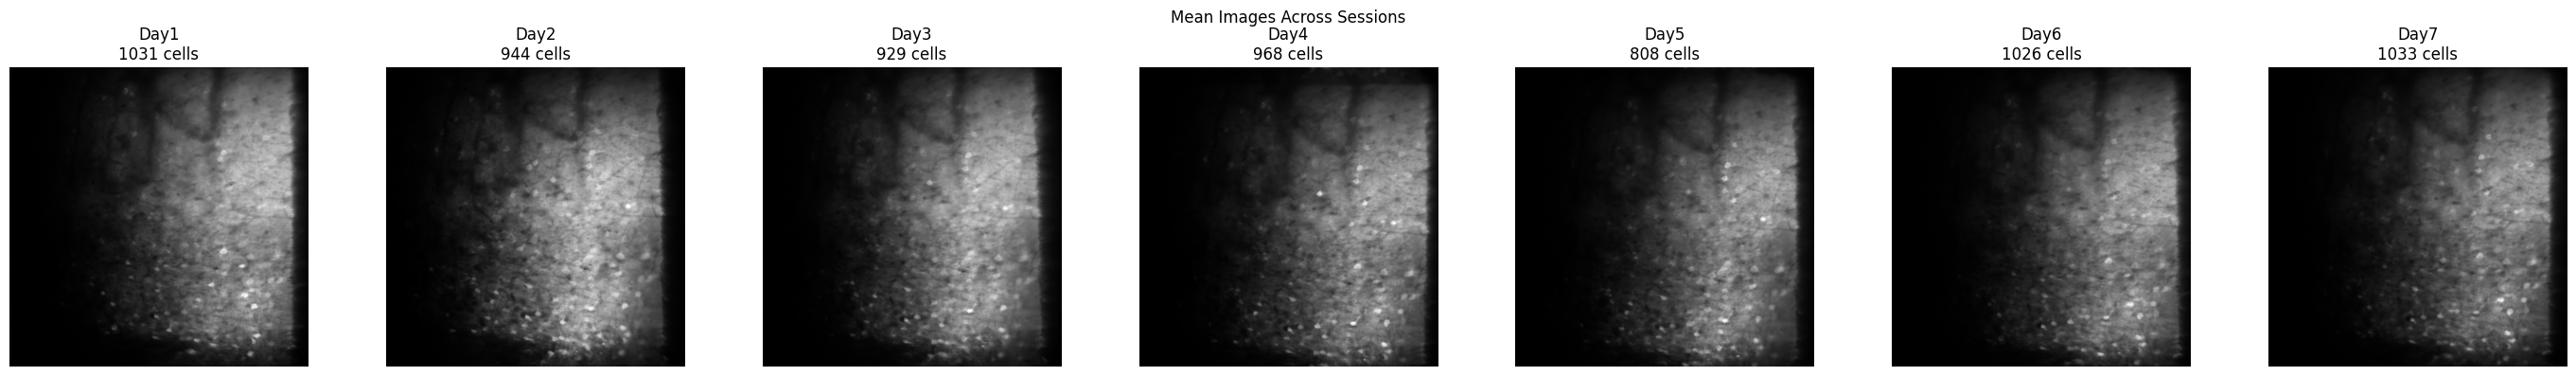

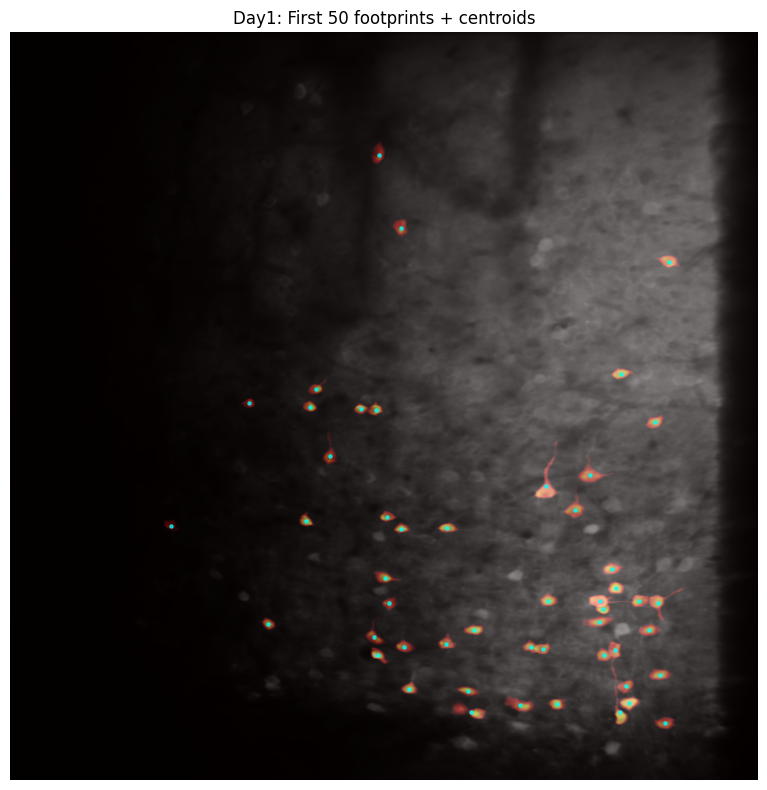

In [3]:
import matplotlib.pyplot as plt

# Plot all mean images side by side
fig, axes = plt.subplots(1, 7, figsize=(28, 4))
for i, session in enumerate(all_sessions):
    axes[i].imshow(session['session_data']['mean_img'], cmap='gray')
    axes[i].set_title(f"{session['day_label']}\n{session['session_data']['n_cells']} cells")
    axes[i].axis('off')
plt.suptitle('Mean Images Across Sessions')
plt.tight_layout()
plt.show()

# For Day1, overlay first 50 cell footprints on the mean image
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(all_sessions[0]['session_data']['mean_img'], cmap='gray')

# Sum the first 50 footprints into a single overlay
overlay = np.sum(all_sessions[0]['footprints'][:50], axis=0)
ax.imshow(overlay, cmap='hot', alpha=0.4)

# Plot centroids
ax.scatter(all_sessions[0]['centroids'][:50, 1], 
           all_sessions[0]['centroids'][:50, 0], 
           s=5, c='cyan', alpha=0.7)
ax.set_title('Day1: First 50 footprints + centroids')
ax.axis('off')
plt.tight_layout()
plt.show()

**align FOVs**

In [4]:
from skimage.registration import phase_cross_correlation
from scipy.ndimage import shift as ndi_shift

# ============================================================
# Function 1: Compute shifts to align all FOVs to a reference
# ============================================================
def align_fovs(all_sessions, reference_day='Day2'):
    """
    Compute rigid (translation) shifts to align all session FOVs
    to a reference session using phase cross-correlation on mean images.
    
    Parameters
    ----------
    all_sessions : list of dicts
        Output from load_all_sessions
    reference_day : str
        Day label to use as reference (e.g., 'Day2')
    
    Returns
    -------
    shifts : dict
        {day_label: (y_shift, x_shift)} for each session.
        Reference session has (0, 0).
    """
    # Find the reference session
    ref_idx = None
    for i, session in enumerate(all_sessions):
        if session['day_label'] == reference_day:
            ref_idx = i
            break
    
    if ref_idx is None:
        raise ValueError(f"Reference day '{reference_day}' not found. "
                         f"Available: {[s['day_label'] for s in all_sessions]}")
    
    ref_img = all_sessions[ref_idx]['session_data']['mean_img']
    print(f"Reference session: {reference_day}\n")
    
    shifts = {}
    for session in all_sessions:
        day = session['day_label']
        
        if day == reference_day:
            shifts[day] = (0.0, 0.0)
            print(f"  {day}: reference (0, 0)")
            continue
        
        moving_img = session['session_data']['mean_img']
        
        # Phase cross-correlation to find shift
        shift_yx, error, diffphase = phase_cross_correlation(
            ref_img, moving_img, upsample_factor=10
        )
        
        shifts[day] = (shift_yx[0], shift_yx[1])
        print(f"  {day}: shift = ({shift_yx[0]:.2f}, {shift_yx[1]:.2f}) pixels")
    
    return shifts


# ============================================================
# Function 2: Apply shifts to centroids and footprints
# ============================================================
def apply_shifts(all_sessions, shifts):
    """
    Apply translation shifts to centroids and footprints so all
    sessions are in the reference session's coordinate space.
    
    Parameters
    ----------
    all_sessions : list of dicts
        Output from load_all_sessions
    shifts : dict
        Output from align_fovs
    
    Returns
    -------
    all_sessions : list of dicts
        Same structure, with added keys:
        'aligned_centroids' : np.ndarray (n_cells, 2) - shifted centroids
        'aligned_mean_img'  : np.ndarray - shifted mean image
    """
    for session in all_sessions:
        day = session['day_label']
        dy, dx = shifts[day]
        
        # Shift centroids
        aligned_centroids = session['centroids'].copy()
        aligned_centroids[:, 0] += dy  # y
        aligned_centroids[:, 1] += dx  # x
        session['aligned_centroids'] = aligned_centroids
        
        # Shift mean image (for visualization/verification)
        aligned_img = ndi_shift(
            session['session_data']['mean_img'], 
            shift=(dy, dx), 
            mode='constant', 
            cval=0
        )
        session['aligned_mean_img'] = aligned_img
        
        print(f"  {day}: applied shift ({dy:.2f}, {dx:.2f})")
    
    return all_sessions


# ============================================================
# Function 3: Visualize alignment quality
# ============================================================
def visualize_alignment(all_sessions, reference_day='Day2'):
    """
    Overlay aligned mean images on the reference to verify alignment.
    Shows before and after for each session.
    
    Parameters
    ----------
    all_sessions : list of dicts
        After apply_shifts has been run
    reference_day : str
        Which day was used as reference
    """
    # Find reference
    ref_img = None
    for session in all_sessions:
        if session['day_label'] == reference_day:
            ref_img = session['session_data']['mean_img']
            break
    
    other_sessions = [s for s in all_sessions if s['day_label'] != reference_day]
    n = len(other_sessions)
    
    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))
    if n == 1:
        axes = axes[np.newaxis, :]
    
    for i, session in enumerate(other_sessions):
        day = session['day_label']
        original_img = session['session_data']['mean_img']
        aligned_img = session['aligned_mean_img']
        
        # Before alignment: red = reference, green = moving
        before = np.zeros((*ref_img.shape, 3))
        before[:, :, 0] = ref_img / ref_img.max()
        before[:, :, 1] = original_img / original_img.max()
        
        # After alignment: red = reference, green = aligned
        after = np.zeros((*ref_img.shape, 3))
        after[:, :, 0] = ref_img / ref_img.max()
        after[:, :, 1] = aligned_img / aligned_img.max()
        
        axes[i, 0].imshow(np.clip(before, 0, 1))
        axes[i, 0].set_title(f'{day} vs {reference_day} — BEFORE')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(np.clip(after, 0, 1))
        axes[i, 1].set_title(f'{day} vs {reference_day} — AFTER')
        axes[i, 1].axis('off')
    
    plt.suptitle(f'FOV Alignment (red = {reference_day}, green = other)\nYellow = good overlap', 
                 fontsize=14)
    plt.tight_layout()
    plt.show()

Reference session: Day2

  Day1: shift = (-1.10, -17.00) pixels
  Day2: reference (0, 0)
  Day3: shift = (-6.10, -4.70) pixels
  Day4: shift = (-38.80, -21.90) pixels
  Day5: shift = (-30.60, -12.70) pixels
  Day6: shift = (-24.50, -24.30) pixels
  Day7: shift = (-10.00, -10.80) pixels
  Day1: applied shift (-1.10, -17.00)
  Day2: applied shift (0.00, 0.00)
  Day3: applied shift (-6.10, -4.70)
  Day4: applied shift (-38.80, -21.90)
  Day5: applied shift (-30.60, -12.70)
  Day6: applied shift (-24.50, -24.30)
  Day7: applied shift (-10.00, -10.80)


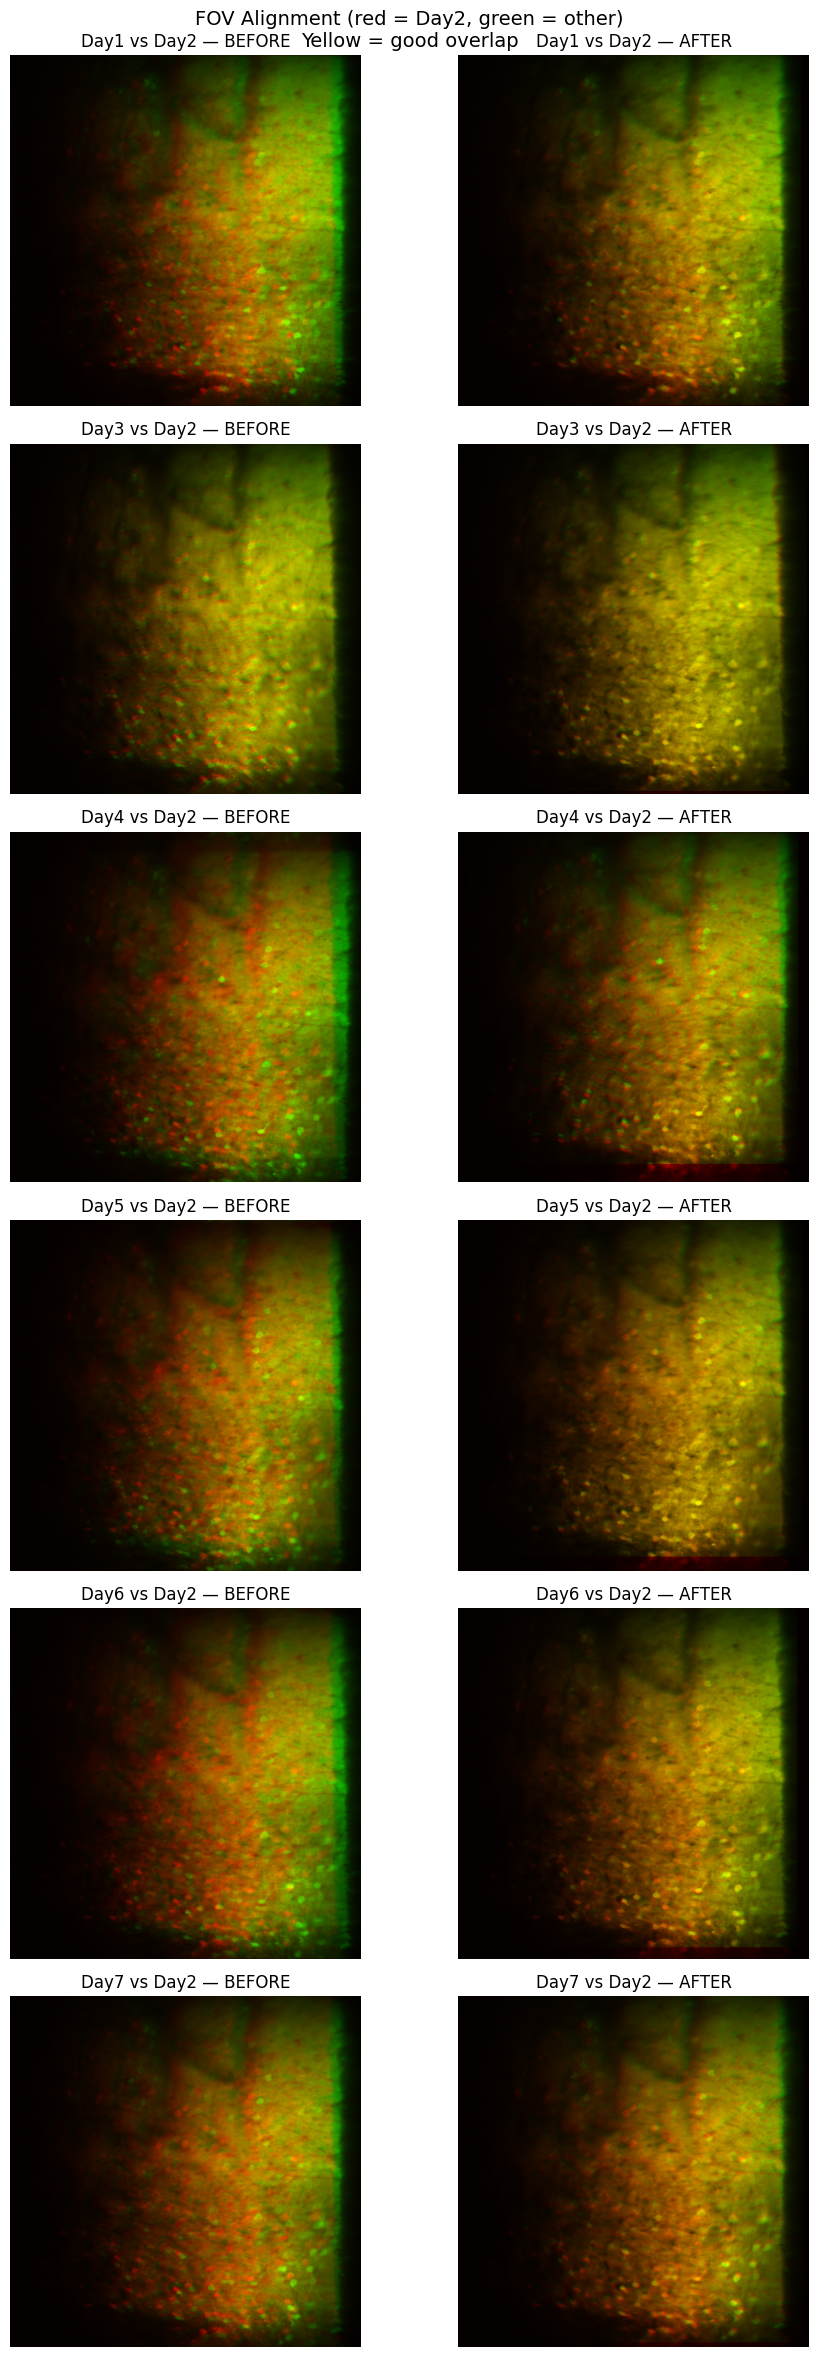

In [5]:
shifts = align_fovs(all_sessions, reference_day='Day2')
all_sessions = apply_shifts(all_sessions, shifts)
visualize_alignment(all_sessions, reference_day='Day2')

**Find matching ROIs**

In [6]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

MICRONS_PER_PIXEL = 0.947408849697405

# ============================================================
# Function 1: Compute pairwise centroid distances
# ============================================================
def compute_pairwise_distances(centroids_a, centroids_b, microns_per_pixel=MICRONS_PER_PIXEL):
    """
    Compute Euclidean distance between all centroid pairs
    across two sessions, in microns.
    
    Parameters
    ----------
    centroids_a : np.ndarray (n_cells_a, 2)
        Aligned centroids from session A (y, x)
    centroids_b : np.ndarray (n_cells_b, 2)
        Aligned centroids from session B (y, x)
    microns_per_pixel : float
    
    Returns
    -------
    dist_matrix : np.ndarray (n_cells_a, n_cells_b)
        Distance in microns between every pair
    """
    dist_pixels = cdist(centroids_a, centroids_b, metric='euclidean')
    dist_microns = dist_pixels * microns_per_pixel
    return dist_microns


# ============================================================
# Function 2: Compute footprint correlations for candidate pairs
# ============================================================
def compute_footprint_correlations(footprints_a, footprints_b, 
                                    candidate_pairs, shifts_a, shifts_b):
    """
    Compute spatial correlation between footprints for candidate pairs.
    Uses a local window around each ROI rather than correlating
    full images, for efficiency.
    
    Parameters
    ----------
    footprints_a : np.ndarray (n_cells_a, Ly, Lx)
        Footprints from session A
    footprints_b : np.ndarray (n_cells_b, Ly, Lx)
        Footprints from session B
    candidate_pairs : list of (idx_a, idx_b) tuples
        Pairs that passed distance threshold
    shifts_a : tuple (dy, dx)
        Shift applied to session A
    shifts_b : tuple (dy, dx)
        Shift applied to session B
    
    Returns
    -------
    correlations : dict
        {(idx_a, idx_b): correlation_value}
    """
    from scipy.ndimage import shift as ndi_shift
    
    Ly, Lx = footprints_a.shape[1], footprints_a.shape[2]
    correlations = {}
    
    for idx_a, idx_b in candidate_pairs:
        # Get individual footprints
        fp_a = footprints_a[idx_a]
        fp_b = footprints_b[idx_b]
        
        # Shift footprints into common reference frame
        fp_a_shifted = ndi_shift(fp_a, shift=(shifts_a[0], shifts_a[1]),
                                  mode='constant', cval=0)
        fp_b_shifted = ndi_shift(fp_b, shift=(shifts_b[0], shifts_b[1]),
                                  mode='constant', cval=0)
        
        # Find the union of nonzero pixels for local window
        mask = (fp_a_shifted > 0) | (fp_b_shifted > 0)
        
        if mask.sum() < 5:
            correlations[(idx_a, idx_b)] = 0.0
            continue
        
        vals_a = fp_a_shifted[mask]
        vals_b = fp_b_shifted[mask]
        
        # Pearson correlation
        if vals_a.std() < 1e-10 or vals_b.std() < 1e-10:
            correlations[(idx_a, idx_b)] = 0.0
            continue
        
        corr = np.corrcoef(vals_a, vals_b)[0, 1]
        correlations[(idx_a, idx_b)] = corr
    
    return correlations


# ============================================================
# Function 3: Match ROIs between two sessions
# ============================================================
def match_rois_pairwise(session_a, session_b, shifts,
                         max_distance_um=15.0, min_correlation=0.3,
                         microns_per_pixel=MICRONS_PER_PIXEL):
    """
    Find optimal one-to-one ROI matches between two sessions using
    Hungarian algorithm with distance and correlation thresholds.
    
    Parameters
    ----------
    session_a : dict
        Session dict from all_sessions
    session_b : dict
        Session dict from all_sessions
    shifts : dict
        {day_label: (dy, dx)} from align_fovs
    max_distance_um : float
        Maximum centroid distance in microns for a valid match
    min_correlation : float
        Minimum footprint correlation for a valid match
    microns_per_pixel : float
    
    Returns
    -------
    matches : list of dicts
        Each dict: {'idx_a', 'idx_b', 'distance_um', 'correlation'}
    """
    day_a = session_a['day_label']
    day_b = session_b['day_label']
    
    centroids_a = session_a['aligned_centroids']
    centroids_b = session_b['aligned_centroids']
    
    # Step 1: Compute all pairwise distances
    dist_matrix = compute_pairwise_distances(centroids_a, centroids_b,
                                              microns_per_pixel)
    
    # Step 2: Find candidate pairs within distance threshold
    candidate_pairs = []
    for i in range(dist_matrix.shape[0]):
        for j in range(dist_matrix.shape[1]):
            if dist_matrix[i, j] <= max_distance_um:
                candidate_pairs.append((i, j))
    
    print(f"  {day_a} vs {day_b}: {len(candidate_pairs)} candidate pairs "
          f"within {max_distance_um} um")
    
    if len(candidate_pairs) == 0:
        return []
    
    # Step 3: Compute footprint correlations for candidates
    shift_a = shifts[day_a]
    shift_b = shifts[day_b]
    
    correlations = compute_footprint_correlations(
        session_a['footprints'], session_b['footprints'],
        candidate_pairs, shift_a, shift_b
    )
    
    # Step 4: Build cost matrix for Hungarian algorithm
    # Only include pairs that pass both thresholds
    valid_pairs = [(i, j) for (i, j) in candidate_pairs
                   if correlations.get((i, j), 0) >= min_correlation]
    
    print(f"  {day_a} vs {day_b}: {len(valid_pairs)} pairs pass correlation "
          f"threshold ({min_correlation})")
    
    if len(valid_pairs) == 0:
        return []
    
    # Get unique ROI indices involved
    unique_a = sorted(set(i for i, j in valid_pairs))
    unique_b = sorted(set(j for i, j in valid_pairs))
    
    # Map to dense indices for cost matrix
    map_a = {idx: k for k, idx in enumerate(unique_a)}
    map_b = {idx: k for k, idx in enumerate(unique_b)}
    
    # Cost = distance (we want to minimize), but only for valid pairs
    # Invalid entries get a very high cost
    cost_matrix = np.full((len(unique_a), len(unique_b)), 1e6)
    
    for i, j in valid_pairs:
        cost_matrix[map_a[i], map_b[j]] = dist_matrix[i, j]
    
    # Hungarian algorithm
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    # Filter out dummy assignments (cost = 1e6)
    matches = []
    for r, c in zip(row_ind, col_ind):
        if cost_matrix[r, c] < 1e6:
            idx_a = unique_a[r]
            idx_b = unique_b[c]
            matches.append({
                'idx_a': idx_a,
                'idx_b': idx_b,
                'distance_um': dist_matrix[idx_a, idx_b],
                'correlation': correlations[(idx_a, idx_b)]
            })
    
    print(f"  {day_a} vs {day_b}: {len(matches)} final matches\n")
    return matches


# ============================================================
# Function 4: Match all sessions against reference
# ============================================================
def match_across_all_sessions(all_sessions, shifts, reference_day='Day2',
                               max_distance_um=15.0, min_correlation=0.3):
    """
    Match ROIs from every session to the reference session,
    then build a registration matrix.
    
    Parameters
    ----------
    all_sessions : list of dicts
    shifts : dict
        From align_fovs
    reference_day : str
    max_distance_um : float
    min_correlation : float
    
    Returns
    -------
    registration_matrix : np.ndarray (n_unique_cells, n_sessions)
        Each row is a unique cell. Entries are the ROI index in that
        session, or -1 if not found.
    all_matches : dict
        {day_label: list of match dicts} for each non-reference session
    day_labels : list of str
        Column labels for the registration matrix
    """
    # Find reference session
    ref_session = None
    ref_idx = None
    for i, session in enumerate(all_sessions):
        if session['day_label'] == reference_day:
            ref_session = session
            ref_idx = i
            break
    
    day_labels = [s['day_label'] for s in all_sessions]
    n_sessions = len(all_sessions)
    n_ref_cells = ref_session['session_data']['n_cells']
    
    # Match each session to reference
    all_matches = {}
    for session in all_sessions:
        if session['day_label'] == reference_day:
            continue
        
        matches = match_rois_pairwise(
            ref_session, session, shifts,
            max_distance_um=max_distance_um,
            min_correlation=min_correlation
        )
        all_matches[session['day_label']] = matches
    
    # Build registration matrix
    # Start with reference cells as rows
    # Each row = one unique cell (defined by its reference session ROI)
    registration_matrix = np.full((n_ref_cells, n_sessions), -1, dtype=int)
    
    # Fill in reference column
    ref_col = day_labels.index(reference_day)
    registration_matrix[:, ref_col] = np.arange(n_ref_cells)
    
    # Fill in other sessions
    for day, matches in all_matches.items():
        col = day_labels.index(day)
        for match in matches:
            ref_roi = match['idx_a']  # index in reference session
            other_roi = match['idx_b']  # index in other session
            registration_matrix[ref_roi, col] = other_roi
    
    # Count how many sessions each cell was found in
    sessions_per_cell = np.sum(registration_matrix >= 0, axis=1)
    
    # Summary
    print("=" * 50)
    print("Registration Summary")
    print("=" * 50)
    print(f"Reference: {reference_day} ({n_ref_cells} cells)")
    print(f"Total sessions: {n_sessions}")
    print()
    for n in range(1, n_sessions + 1):
        count = np.sum(sessions_per_cell == n)
        if count > 0:
            print(f"  Found in {n}/{n_sessions} sessions: {count} cells")
    print(f"\n  Tracked in 2+ sessions: {np.sum(sessions_per_cell >= 2)} cells")
    print(f"  Tracked in all {n_sessions} sessions: "
          f"{np.sum(sessions_per_cell == n_sessions)} cells")
    
    return registration_matrix, all_matches, day_labels


# ============================================================
# Function 5: Summarize match quality
# ============================================================
def plot_match_quality(all_matches, reference_day='Day2'):
    """
    Plot distributions of distances and correlations for all matches.
    
    Parameters
    ----------
    all_matches : dict
        From match_across_all_sessions
    reference_day : str
    """
    n_other = len(all_matches)
    fig, axes = plt.subplots(n_other, 2, figsize=(10, 3 * n_other))
    if n_other == 1:
        axes = axes[np.newaxis, :]
    
    for i, (day, matches) in enumerate(sorted(all_matches.items())):
        if len(matches) == 0:
            axes[i, 0].set_title(f'{reference_day} vs {day}: no matches')
            axes[i, 1].set_title(f'{reference_day} vs {day}: no matches')
            continue
        
        distances = [m['distance_um'] for m in matches]
        corrs = [m['correlation'] for m in matches]
        
        axes[i, 0].hist(distances, bins=30, color='steelblue', edgecolor='white')
        axes[i, 0].set_xlabel('Distance (um)')
        axes[i, 0].set_ylabel('Count')
        axes[i, 0].set_title(f'{reference_day} vs {day}: distances '
                              f'(n={len(matches)})')
        
        axes[i, 1].hist(corrs, bins=30, color='coral', edgecolor='white')
        axes[i, 1].set_xlabel('Footprint correlation')
        axes[i, 1].set_ylabel('Count')
        axes[i, 1].set_title(f'{reference_day} vs {day}: correlations')
    
    plt.suptitle('Match Quality', fontsize=14)
    plt.tight_layout()
    plt.show()

  Day2 vs Day1: 2483 candidate pairs within 15.0 um
  Day2 vs Day1: 689 pairs pass correlation threshold (0.3)
  Day2 vs Day1: 573 final matches

  Day2 vs Day3: 2429 candidate pairs within 15.0 um
  Day2 vs Day3: 790 pairs pass correlation threshold (0.3)
  Day2 vs Day3: 654 final matches

  Day2 vs Day4: 2414 candidate pairs within 15.0 um
  Day2 vs Day4: 526 pairs pass correlation threshold (0.3)
  Day2 vs Day4: 409 final matches

  Day2 vs Day5: 2190 candidate pairs within 15.0 um
  Day2 vs Day5: 737 pairs pass correlation threshold (0.3)
  Day2 vs Day5: 612 final matches

  Day2 vs Day6: 2512 candidate pairs within 15.0 um
  Day2 vs Day6: 753 pairs pass correlation threshold (0.3)
  Day2 vs Day6: 631 final matches

  Day2 vs Day7: 2599 candidate pairs within 15.0 um
  Day2 vs Day7: 649 pairs pass correlation threshold (0.3)
  Day2 vs Day7: 514 final matches

Registration Summary
Reference: Day2 (944 cells)
Total sessions: 7

  Found in 1/7 sessions: 74 cells
  Found in 2/7 session

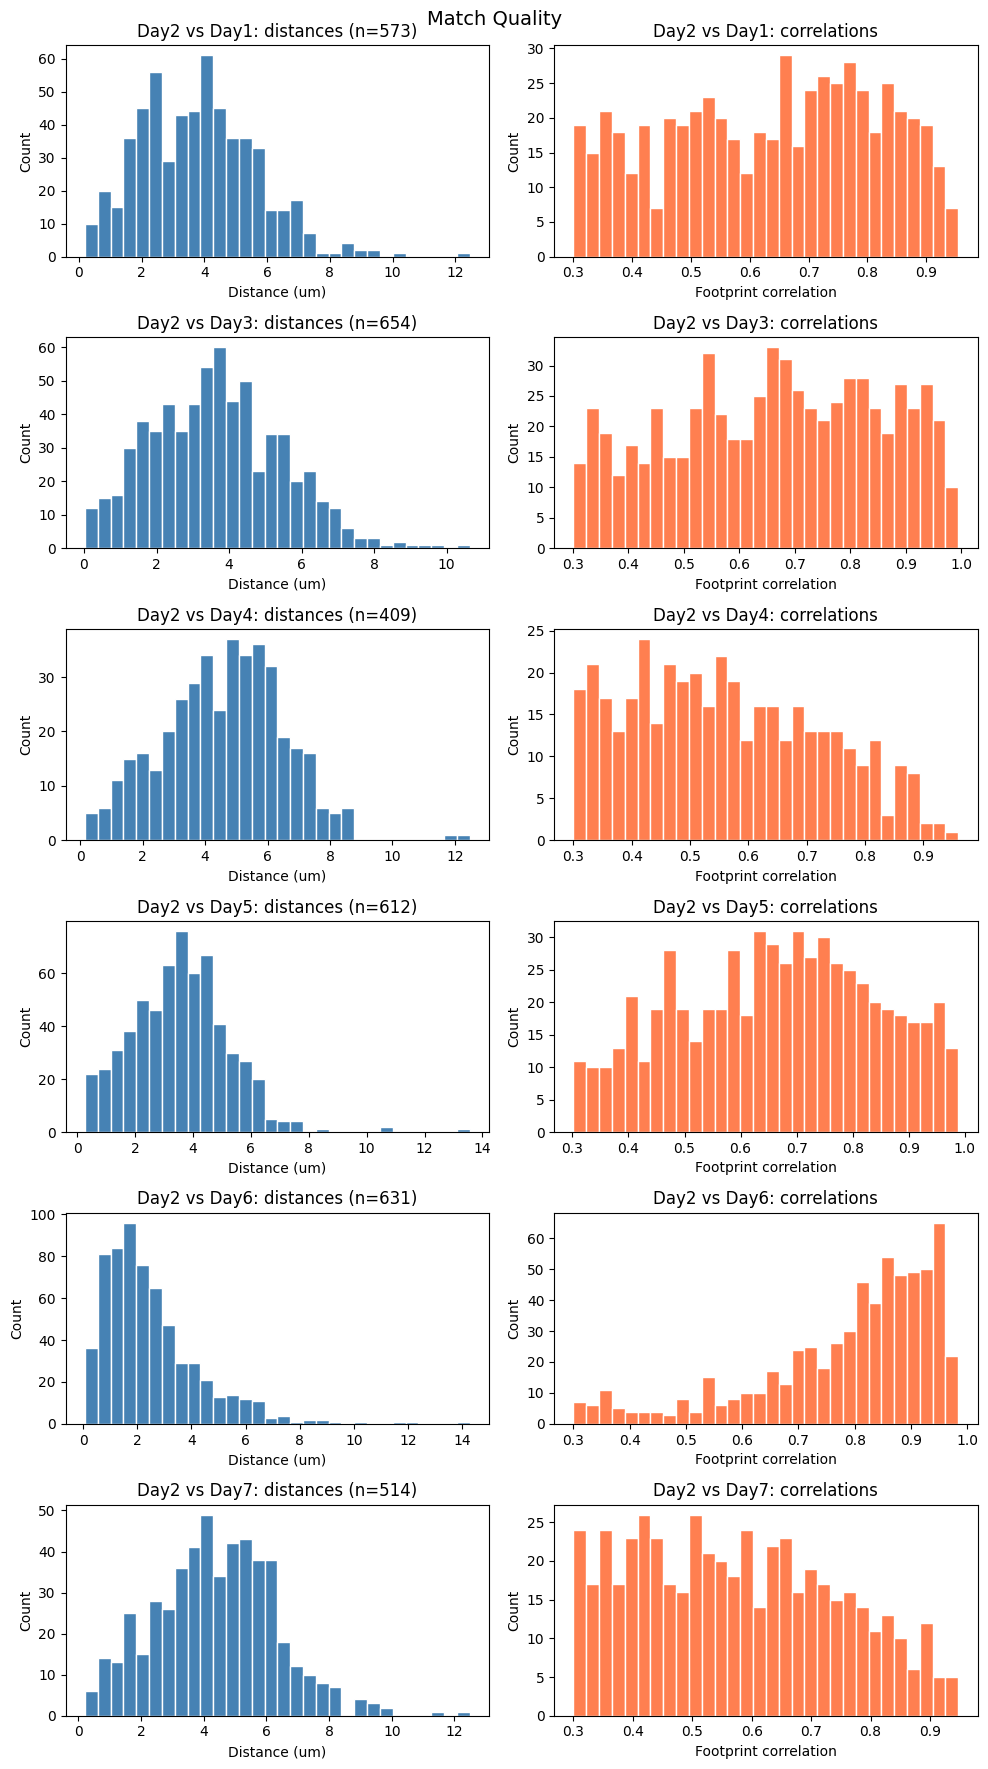

In [7]:
registration_matrix, all_matches, day_labels = match_across_all_sessions(
    all_sessions, shifts, 
    reference_day='Day2',
    max_distance_um=15.0, 
    min_correlation=0.3
)

plot_match_quality(all_matches, reference_day='Day2')

**manual inspection**

In [8]:
%matplotlib qt
import matplotlib.pyplot as plt
from matplotlib.widgets import Button
from scipy.ndimage import shift as ndi_shift
import numpy as np
import h5py

# ============================================================
# Function 1: Filter registration matrix to specific sessions
# ============================================================
def get_tracked_cells(registration_matrix, day_labels, required_days):
    """
    Find cells that are present in ALL specified sessions.
    
    Parameters
    ----------
    registration_matrix : np.ndarray (n_cells, n_sessions)
        From match_across_all_sessions
    day_labels : list of str
        Column labels
    required_days : list of str
        Which days the cell must be present in, e.g. ['Day1','Day3','Day5','Day7']
    
    Returns
    -------
    tracked_cells : np.ndarray
        Row indices into registration_matrix for cells present in all required days
    tracked_matrix : np.ndarray
        Subset of registration_matrix for tracked cells, columns = required days only
    """
    required_cols = [day_labels.index(d) for d in required_days]
    
    # Cell must have valid ROI index (>= 0) in all required sessions
    mask = np.all(registration_matrix[:, required_cols] >= 0, axis=1)
    tracked_cells = np.where(mask)[0]
    tracked_matrix = registration_matrix[np.ix_(tracked_cells, required_cols)]
    
    print(f"Required sessions: {required_days}")
    print(f"Cells tracked across all {len(required_days)} sessions: {len(tracked_cells)}")
    
    return tracked_cells, tracked_matrix

def filter_registration_matrix(all_sessions, registration_matrix, day_labels,
                                required_days, shifts,
                                max_footprint_pixels=500,
                                auto_accept_corr=0.7,
                                auto_accept_dist=5.0,
                                microns_per_pixel=MICRONS_PER_PIXEL):
    """
    Automatically filter the registration matrix before manual inspection.
    
    For each cell tracked across required_days:
      - Auto-REJECT if any footprint is abnormally large (artifact)
      - Auto-ACCEPT if ALL pairwise matches have high correlation 
        AND small distance
      - MANUAL review for everything else
    
    Parameters
    ----------
    all_sessions : list of dicts
    registration_matrix : np.ndarray
    day_labels : list of str
    required_days : list of str
    shifts : dict
    max_footprint_pixels : int
    auto_accept_corr : float
        Min correlation across all session pairs for auto-accept
    auto_accept_dist : float
        Max distance (um) across all session pairs for auto-accept
    
    Returns
    -------
    filtered_matrix : np.ndarray
        Registration matrix with artifact matches set to -1
    cell_categories : dict
        {cell_row: 'auto_accept', 'auto_reject', or 'manual_review'}
    filter_report : dict
    """
    from scipy.ndimage import shift as ndi_shift
    
    filtered_matrix = registration_matrix.copy()
    required_cols = [day_labels.index(d) for d in required_days]
    
    # Build session lookup
    session_lookup = {}
    for s in all_sessions:
        session_lookup[s['day_label']] = s
    
    # Find cells present in all required sessions
    mask = np.all(registration_matrix[:, required_cols] >= 0, axis=1)
    candidate_rows = np.where(mask)[0]
    
    cell_categories = {}
    reject_details = []
    accept_details = []
    
    print(f"Evaluating {len(candidate_rows)} cells tracked across {required_days}...")
    
    for count, row in enumerate(candidate_rows):
        if (count + 1) % 50 == 0:
            print(f"  Processing cell {count+1}/{len(candidate_rows)}...")
        
        # --- Check 1: Footprint sizes ---
        is_artifact = False
        for col in required_cols:
            roi_idx = registration_matrix[row, col]
            day = day_labels[col]
            session = session_lookup[day]
            fp_size = np.sum(session['footprints'][roi_idx] > 0)
            
            if fp_size > max_footprint_pixels:
                is_artifact = True
                reject_details.append({
                    'row': row, 'day': day,
                    'roi_idx': roi_idx, 'fp_size': fp_size
                })
                break
        
        if is_artifact:
            # Remove from all required sessions
            for col in required_cols:
                filtered_matrix[row, col] = -1
            cell_categories[row] = 'auto_reject'
            continue
        
        # --- Check 2: Pairwise distances and correlations ---
        # Compare each session to the first required session as anchor
        anchor_day = required_days[0]
        anchor_session = session_lookup[anchor_day]
        anchor_col = day_labels.index(anchor_day)
        anchor_roi = registration_matrix[row, anchor_col]
        anchor_cent = anchor_session['aligned_centroids'][anchor_roi]
        
        shift_anchor = shifts[anchor_day]
        fp_anchor = ndi_shift(
            anchor_session['footprints'][anchor_roi],
            shift=(shift_anchor[0], shift_anchor[1]),
            mode='constant', cval=0
        )
        
        all_high_quality = True
        worst_corr = 1.0
        worst_dist = 0.0
        
        for day in required_days[1:]:
            session = session_lookup[day]
            col = day_labels.index(day)
            roi_idx = registration_matrix[row, col]
            
            # Distance
            cent = session['aligned_centroids'][roi_idx]
            dist_px = np.sqrt((anchor_cent[0] - cent[0])**2 + 
                              (anchor_cent[1] - cent[1])**2)
            dist_um = dist_px * microns_per_pixel
            
            # Correlation
            shift_other = shifts[day]
            fp_other = ndi_shift(
                session['footprints'][roi_idx],
                shift=(shift_other[0], shift_other[1]),
                mode='constant', cval=0
            )
            
            union_mask = (fp_anchor > 0) | (fp_other > 0)
            if union_mask.sum() < 5:
                all_high_quality = False
                break
            
            vals_a = fp_anchor[union_mask]
            vals_b = fp_other[union_mask]
            
            if vals_a.std() < 1e-10 or vals_b.std() < 1e-10:
                all_high_quality = False
                break
            
            corr = np.corrcoef(vals_a, vals_b)[0, 1]
            
            worst_corr = min(worst_corr, corr)
            worst_dist = max(worst_dist, dist_um)
            
            if corr < auto_accept_corr or dist_um > auto_accept_dist:
                all_high_quality = False
                break
        
        if all_high_quality:
            cell_categories[row] = 'auto_accept'
            accept_details.append({
                'row': row, 
                'worst_corr': worst_corr, 
                'worst_dist': worst_dist
            })
        else:
            cell_categories[row] = 'manual_review'
    
    # Summary
    n_accept = sum(1 for v in cell_categories.values() if v == 'auto_accept')
    n_reject = sum(1 for v in cell_categories.values() if v == 'auto_reject')
    n_manual = sum(1 for v in cell_categories.values() if v == 'manual_review')
    
    # Footprint size stats for context
    ref_session = session_lookup[required_days[0]]
    all_sizes = [np.sum(ref_session['footprints'][i] > 0)
                 for i in range(ref_session['session_data']['n_cells'])]
    
    print("\n" + "=" * 50)
    print("Automatic Filtering Report")
    print("=" * 50)
    print(f"Cells tracked across all required sessions: {len(candidate_rows)}")
    print(f"\n  Auto-accept: {n_accept}")
    print(f"    (all pairs: dist < {auto_accept_dist}um AND corr > {auto_accept_corr})")
    print(f"  Auto-reject: {n_reject}")
    print(f"    (footprint > {max_footprint_pixels}px)")
    print(f"  Manual review: {n_manual}")
    print(f"\nFootprint size stats: median={np.median(all_sizes):.0f}px, "
          f"mean={np.mean(all_sizes):.0f}px, max={np.max(all_sizes)}px")
    
    if accept_details:
        worst_corrs = [d['worst_corr'] for d in accept_details]
        worst_dists = [d['worst_dist'] for d in accept_details]
        print(f"\nAuto-accepted cells:")
        print(f"  Worst correlation: min={min(worst_corrs):.2f}, "
              f"median={np.median(worst_corrs):.2f}")
        print(f"  Worst distance: max={max(worst_dists):.1f}um, "
              f"median={np.median(worst_dists):.1f}um")
    
    filter_report = {
        'n_candidates': len(candidate_rows),
        'n_auto_accept': n_accept,
        'n_auto_reject': n_reject,
        'n_manual_review': n_manual,
        'reject_details': reject_details,
        'accept_details': accept_details,
        'footprint_stats': {
            'median': np.median(all_sizes),
            'mean': np.mean(all_sizes),
            'max': np.max(all_sizes)
        }
    }
    
    return filtered_matrix, cell_categories, filter_report

# ============================================================
# Function 2: Plot a single cell across all required sessions
# ============================================================
def plot_cell_across_sessions(all_sessions, registration_matrix, day_labels,
                               cell_row, required_days, shifts,
                               crop_size=40, microns_per_pixel=MICRONS_PER_PIXEL):
    """
    Show one tracked cell's footprint across all required sessions,
    with correlation and distance to anchor session displayed.
    """
    from scipy.ndimage import shift as ndi_shift
    
    required_cols = [day_labels.index(d) for d in required_days]
    n_days = len(required_days)
    
    # Build session lookup
    session_lookup = {}
    for s in all_sessions:
        session_lookup[s['day_label']] = s
    
    # Get anchor footprint (first required day)
    anchor_day = required_days[0]
    anchor_session = session_lookup[anchor_day]
    anchor_col = day_labels.index(anchor_day)
    anchor_roi = registration_matrix[cell_row, anchor_col]
    anchor_cent = anchor_session['aligned_centroids'][anchor_roi]
    shift_anchor = shifts[anchor_day]
    fp_anchor = ndi_shift(
        anchor_session['footprints'][anchor_roi],
        shift=(shift_anchor[0], shift_anchor[1]),
        mode='constant', cval=0
    )
    
    # Compute correlations and distances to anchor for all sessions
    corrs = {}
    dists = {}
    for day in required_days:
        session = session_lookup[day]
        col = day_labels.index(day)
        roi_idx = registration_matrix[cell_row, col]
        
        # Distance
        cent = session['aligned_centroids'][roi_idx]
        dist_px = np.sqrt((anchor_cent[0] - cent[0])**2 + 
                          (anchor_cent[1] - cent[1])**2)
        dists[day] = dist_px * microns_per_pixel
        
        if day == anchor_day:
            corrs[day] = 1.0
            continue
        
        # Correlation
        shift_other = shifts[day]
        fp_other = ndi_shift(
            session['footprints'][roi_idx],
            shift=(shift_other[0], shift_other[1]),
            mode='constant', cval=0
        )
        
        union_mask = (fp_anchor > 0) | (fp_other > 0)
        if union_mask.sum() < 5:
            corrs[day] = 0.0
            continue
        
        vals_a = fp_anchor[union_mask]
        vals_b = fp_other[union_mask]
        
        if vals_a.std() < 1e-10 or vals_b.std() < 1e-10:
            corrs[day] = 0.0
            continue
        
        corrs[day] = np.corrcoef(vals_a, vals_b)[0, 1]
    
    # Get crop center from mean of all aligned centroids
    all_cents = []
    for col, day in zip(required_cols, required_days):
        roi_idx = registration_matrix[cell_row, col]
        session = session_lookup[day]
        all_cents.append(session['aligned_centroids'][roi_idx])
    all_cents = np.array(all_cents)
    mid_y = int(np.mean(all_cents[:, 0]))
    mid_x = int(np.mean(all_cents[:, 1]))
    
    Ly = all_sessions[0]['session_data']['Ly']
    Lx = all_sessions[0]['session_data']['Lx']
    y_min = max(0, mid_y - crop_size)
    y_max = min(Ly, mid_y + crop_size)
    x_min = max(0, mid_x - crop_size)
    x_max = min(Lx, mid_x + crop_size)
    
    # Plot
    fig, axes = plt.subplots(1, n_days + 1, figsize=(4 * (n_days + 1), 4))
    
    footprints_cropped = []
    
    for i, (col, day) in enumerate(zip(required_cols, required_days)):
        roi_idx = registration_matrix[cell_row, col]
        session = session_lookup[day]
        
        shift_yx = shifts[day]
        fp = ndi_shift(session['footprints'][roi_idx],
                       shift=(shift_yx[0], shift_yx[1]),
                       mode='constant', cval=0)
        
        fp_crop = fp[y_min:y_max, x_min:x_max]
        mean_crop = session['aligned_mean_img'][y_min:y_max, x_min:x_max]
        footprints_cropped.append(fp_crop)
        
        if fp_crop.max() > 0:
            fp_norm = fp_crop / fp_crop.max()
        else:
            fp_norm = fp_crop
        
        axes[i].imshow(mean_crop, cmap='gray')
        overlay = np.zeros((*fp_crop.shape, 4))
        overlay[:, :, 1] = fp_norm
        overlay[:, :, 3] = fp_norm * 0.6
        axes[i].imshow(overlay)
        
        # Title with correlation and distance
        if day == anchor_day:
            axes[i].set_title(f"{day} (anchor)\nROI {roi_idx}", fontsize=9)
        else:
            axes[i].set_title(f"{day}\nROI {roi_idx}\n"
                              f"corr={corrs[day]:.2f}, dist={dists[day]:.1f}um",
                              fontsize=9)
        axes[i].axis('off')
    
    # Overlay panel
    colors = plt.cm.hsv(np.linspace(0, 0.85, n_days))
    mean_crop = session_lookup[required_days[0]]['aligned_mean_img'][y_min:y_max, x_min:x_max]
    
    axes[n_days].imshow(mean_crop, cmap='gray')
    overlay_all = np.zeros((*footprints_cropped[0].shape, 4))
    
    for j, fp_crop in enumerate(footprints_cropped):
        if fp_crop.max() > 0:
            fp_norm = fp_crop / fp_crop.max()
        else:
            fp_norm = fp_crop
        mask = fp_norm > 0.1
        overlay_all[mask, 0] += colors[j, 0] * fp_norm[mask]
        overlay_all[mask, 1] += colors[j, 1] * fp_norm[mask]
        overlay_all[mask, 2] += colors[j, 2] * fp_norm[mask]
        overlay_all[mask, 3] = np.maximum(overlay_all[mask, 3], fp_norm[mask] * 0.6)
    
    overlay_all[:, :, :3] = np.clip(overlay_all[:, :, :3], 0, 1)
    axes[n_days].imshow(overlay_all)
    
    # Overlay title with min correlation and max distance
    min_corr = min(v for k, v in corrs.items() if k != anchor_day)
    max_dist = max(v for k, v in dists.items() if k != anchor_day)
    axes[n_days].set_title(f"All overlaid\nmin corr={min_corr:.2f}\n"
                           f"max dist={max_dist:.1f}um", fontsize=9)
    axes[n_days].axis('off')
    
    fig.suptitle(f"Cell {cell_row} (anchor: {anchor_day} ROI {anchor_roi})",
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig

# ============================================================
# Function 3: Interactive inspection of tracked cells
# ============================================================
def inspect_tracked_cells(all_sessions, filtered_matrix, day_labels,
                          required_days, shifts, cell_categories,
                          crop_size=40):
    """
    Interactive inspection — only shows manual_review cells.
    Auto-accepted and auto-rejected are already handled.
    """
    required_cols = [day_labels.index(d) for d in required_days]
    
    # Only inspect manual_review cells
    manual_rows = sorted([row for row, cat in cell_categories.items() 
                          if cat == 'manual_review'])
    
    total = len(manual_rows)
    n_auto_accept = sum(1 for v in cell_categories.values() if v == 'auto_accept')
    n_auto_reject = sum(1 for v in cell_categories.values() if v == 'auto_reject')
    
    print(f"Auto-accepted: {n_auto_accept} cells (skipped)")
    print(f"Auto-rejected: {n_auto_reject} cells (skipped)")
    print(f"Manual review: {total} cells\n")
    
    if total == 0:
        print("Nothing to manually review!")
        decisions = {}
        verified_matrix = filtered_matrix.copy()
        return verified_matrix, decisions
    
    print(f"Controls: 'a'/Right = accept, 'r'/'x' = reject, "
          f"'b'/Left = back, 'q' = quit\n")
    
    decisions = {}
    current_idx = [0]
    fig = [None]
    
    def show_current():
        cell_row = manual_rows[current_idx[0]]
        
        if fig[0] is not None:
            plt.close(fig[0])
        
        fig[0] = plot_cell_across_sessions(
            all_sessions, filtered_matrix, day_labels,
            cell_row, required_days, shifts, crop_size
        )
        
        status = decisions.get(cell_row, None)
        status_str = "NOT REVIEWED" if status is None else status.upper()
        color = 'black' if status is None else ('green' if status == 'accept' else 'red')
        
        fig[0].suptitle(
            f"Manual Review {current_idx[0]+1}/{total} (row {cell_row}) | "
            f"Status: {status_str}",
            fontsize=12, color=color, fontweight='bold'
        )
        
        fig[0].canvas.mpl_connect('key_press_event', on_key)
        fig[0].canvas.draw()
        plt.show(block=False)
    
    def on_key(event):
        cell_row = manual_rows[current_idx[0]]
        
        if event.key in ['a', 'right']:
            decisions[cell_row] = 'accept'
            print(f"  {current_idx[0]+1}/{total} (row {cell_row}): ACCEPTED")
            if current_idx[0] < total - 1:
                current_idx[0] += 1
                show_current()
            else:
                print("\nReached the end! Press 'q' to finish.")
                
        elif event.key in ['r', 'x']:
            decisions[cell_row] = 'reject'
            print(f"  {current_idx[0]+1}/{total} (row {cell_row}): REJECTED")
            if current_idx[0] < total - 1:
                current_idx[0] += 1
                show_current()
            else:
                print("\nReached the end! Press 'q' to finish.")
                
        elif event.key in ['b', 'left']:
            if current_idx[0] > 0:
                current_idx[0] -= 1
                show_current()
                
        elif event.key == 'q':
            if fig[0] is not None:
                plt.close(fig[0])
            print("\nQuitting inspection.")
    
    show_current()
    plt.show()
    
    # Build verified matrix
    verified_matrix = filtered_matrix.copy()
    
    for cell_row, decision in decisions.items():
        if decision == 'reject':
            for col in required_cols:
                verified_matrix[cell_row, col] = -1
    
    # Final summary
    n_manual_accept = sum(1 for d in decisions.values() if d == 'accept')
    n_manual_reject = sum(1 for d in decisions.values() if d == 'reject')
    n_unreviewed = total - len(decisions)
    
    final_tracked = np.sum(
        np.all(verified_matrix[:, required_cols] >= 0, axis=1)
    )
    
    print(f"\n" + "=" * 50)
    print(f"Final Summary")
    print(f"=" * 50)
    print(f"  Auto-accepted: {n_auto_accept}")
    print(f"  Manually accepted: {n_manual_accept}")
    print(f"  Auto-rejected: {n_auto_reject}")
    print(f"  Manually rejected: {n_manual_reject}")
    print(f"  Unreviewed: {n_unreviewed}")
    print(f"\n  Final tracked cells: {final_tracked}")
    
    return verified_matrix, decisions


# ============================================================
# Function 4: Save results to HDF5
# ============================================================
def save_tracking_results(verified_matrix, registration_matrix, 
                          day_labels, decisions, required_days, 
                          all_sessions, shifts, save_path):
    """
    Save complete tracking results to HDF5.
    
    The file contains:
      - verified_matrix: registration matrix after manual inspection
      - original_matrix: registration matrix before inspection
      - day_labels: session labels
      - required_days: which sessions were required for tracking
      - decisions: accept/reject for each inspected cell
      - per-session ROI mapping: for each session, which ROI index
        corresponds to each tracked cell
    """
    tracked_cells, tracked_matrix = get_tracked_cells(
        verified_matrix, day_labels, required_days
    )
    
    with h5py.File(save_path, 'w') as f:
        # Matrices
        f.create_dataset('verified_matrix', data=verified_matrix)
        f.create_dataset('original_matrix', data=registration_matrix)
        f.create_dataset('tracked_matrix', data=tracked_matrix)
        f.create_dataset('tracked_cell_rows', data=tracked_cells)
        
        # Metadata
        f.attrs['day_labels'] = day_labels
        f.attrs['required_days'] = required_days
        f.attrs['n_tracked_cells'] = len(tracked_cells)
        f.attrs['microns_per_pixel'] = MICRONS_PER_PIXEL
        
        # Shifts
        shift_grp = f.create_group('shifts')
        for day, (dy, dx) in shifts.items():
            shift_grp.attrs[day] = [dy, dx]
        
        # Decisions
        if decisions:
            dec_grp = f.create_group('decisions')
            cell_rows = list(decisions.keys())
            dec_values = [decisions[k] for k in cell_rows]
            dec_grp.create_dataset('cell_rows', data=np.array(cell_rows, dtype=int))
            dec_grp.create_dataset('decisions', 
                                   data=np.array(dec_values, dtype='S10'))
        
        # Per-session info
        for session in all_sessions:
            day = session['day_label']
            grp = f.create_group(f'sessions/{day}')
            grp.attrs['n_cells'] = session['session_data']['n_cells']
            grp.attrs['plane0_path'] = str(session['plane0_path'])
            grp.create_dataset('cell_idx', 
                               data=session['session_data']['cell_idx'])
    
    print(f"\nSaved to {save_path}")
    print(f"  Tracked cells ({'/'.join(required_days)}): {len(tracked_cells)}")
    print(f"\nKey datasets in the file:")
    print(f"  'verified_matrix': ({verified_matrix.shape[0]} x {verified_matrix.shape[1]})")
    print(f"    Rows = cells (indexed by ref session ROI)")
    print(f"    Columns = sessions: {day_labels}")
    print(f"    Values = ROI index in that session (-1 if not found)")
    print(f"  'tracked_matrix': ({tracked_matrix.shape[0]} x {tracked_matrix.shape[1]})")
    print(f"    Only cells present in all required sessions")
    print(f"    Columns = {required_days}")
    print(f"  'tracked_cell_rows': row indices into verified_matrix")

In [9]:
%matplotlib qt

In [10]:
import os


required_days = ['Day2', 'Day3', 'Day4', 'Day5', 'Day6', 'Day7']
# required_days = ['Day1','Day2', 'Day3', 'Day4', 'Day5', 'Day6', 'Day7']
day_labels = [s['day_label'] for s in all_sessions]

# Step 1: Auto-filter (accept + reject)
filtered_matrix, cell_categories, filter_report = filter_registration_matrix(
    all_sessions, registration_matrix, day_labels, 
    required_days, shifts,
    max_footprint_pixels=500,
    auto_accept_corr=0.3,
    auto_accept_dist=5.0
)

# Step 2: Manual inspection (only borderline cases)
verified_matrix, decisions = inspect_tracked_cells(
    all_sessions, filtered_matrix, day_labels,
    required_days, shifts, cell_categories
)

# Step 3: Save
save_path = os.path.join(base_dir, "roi_tracking_results.h5")
save_tracking_results(
    verified_matrix, registration_matrix,
    day_labels, decisions, required_days,
    all_sessions, shifts, save_path
)

Evaluating 187 cells tracked across ['Day2', 'Day3', 'Day4', 'Day5', 'Day6', 'Day7']...
  Processing cell 50/187...
  Processing cell 100/187...
  Processing cell 150/187...

Automatic Filtering Report
Cells tracked across all required sessions: 187

  Auto-accept: 48
    (all pairs: dist < 5.0um AND corr > 0.3)
  Auto-reject: 2
    (footprint > 500px)
  Manual review: 137

Footprint size stats: median=156px, mean=171px, max=1055px

Auto-accepted cells:
  Worst correlation: min=0.42, median=0.58
  Worst distance: max=5.0um, median=4.1um
Auto-accepted: 48 cells (skipped)
Auto-rejected: 2 cells (skipped)
Manual review: 137 cells

Controls: 'a'/Right = accept, 'r'/'x' = reject, 'b'/Left = back, 'q' = quit



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.32655548782686e-17..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.027665307745337486..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03157545253634453..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04816409945487976..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04099392518401146..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.025341980159282684..1.0].



Final Summary
  Auto-accepted: 48
  Manually accepted: 0
  Auto-rejected: 2
  Manually rejected: 0
  Unreviewed: 137

  Final tracked cells: 185
Required sessions: ['Day2', 'Day3', 'Day4', 'Day5', 'Day6', 'Day7']
Cells tracked across all 6 sessions: 185

Saved to D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\roi_tracking_results.h5
  Tracked cells (Day2/Day3/Day4/Day5/Day6/Day7): 185

Key datasets in the file:
  'verified_matrix': (944 x 7)
    Rows = cells (indexed by ref session ROI)
    Columns = sessions: ['Day1', 'Day2', 'Day3', 'Day4', 'Day5', 'Day6', 'Day7']
    Values = ROI index in that session (-1 if not found)
  'tracked_matrix': (185 x 6)
    Only cells present in all required sessions
    Columns = ['Day2', 'Day3', 'Day4', 'Day5', 'Day6', 'Day7']
  'tracked_cell_rows': row indices into verified_matrix


  1/137 (row 0): ACCEPTED


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.184761510712e-17..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.032136209309101105..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03215921297669411..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.042615797370672226..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03763893246650696..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.023781850934028625..1.0].


...

  135/137 (row 920): REJECTED


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.3365562668687485e-17..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05177273973822594..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04969613254070282..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0611073337495327..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04835670441389084..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03078092820942402..1.0].


  136/137 (row 932): REJECTED


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.273917486225121e-17..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05259520933032036..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04172710329294205..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06153801828622818..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04606520012021065..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03184547275304794..1.0].


  137/137 (row 938): ACCEPTED

Reached the end! Press 'q' to finish.
  137/137 (row 938): ACCEPTED

Reached the end! Press 'q' to finish.
  137/137 (row 938): ACCEPTED

Reached the end! Press 'q' to finish.

Quitting inspection.


In [11]:
print(f"Decisions made: {len(decisions)}")
print(f"Accepted: {sum(1 for d in decisions.values() if d == 'accept')}")
print(f"Rejected: {sum(1 for d in decisions.values() if d == 'reject')}")

import h5py
with h5py.File(save_path, 'r') as f:
    print("Datasets in file:")
    for key in f.keys():
        if isinstance(f[key], h5py.Dataset):
            print(f"  {key}: {f[key].shape}")
        else:
            print(f"  {key}/ (group)")
    
    tracked = f['tracked_matrix'][:]
    print(f"\nTracked cells: {tracked.shape[0]}")
    print(f"Sessions: {list(f.attrs['required_days'])}")
    print(f"\nFirst 5 rows of tracked_matrix (ROI indices per session):")
    print(tracked[:5])

Decisions made: 137
Accepted: 117
Rejected: 20
Datasets in file:
  original_matrix: (944, 7)
  sessions/ (group)
  shifts/ (group)
  tracked_cell_rows: (185,)
  tracked_matrix: (185, 6)
  verified_matrix: (944, 7)

Tracked cells: 185
Sessions: ['Day2', 'Day3', 'Day4', 'Day5', 'Day6', 'Day7']

First 5 rows of tracked_matrix (ROI indices per session):
[[  0   0   0   1   0   0]
 [  5   3  12   8  17  26]
 [  9  10 488  41  30  11]
 [ 15  15  10  15  24  68]
 [ 19   7   2   3  22  22]]


In [12]:
save_path = os.path.join(base_dir, "roi_tracking_results.h5")
day_labels = [s['day_label'] for s in all_sessions]
save_tracking_results(
    verified_matrix, registration_matrix,
    day_labels, decisions, required_days,
    all_sessions, shifts, save_path
)

Required sessions: ['Day2', 'Day3', 'Day4', 'Day5', 'Day6', 'Day7']
Cells tracked across all 6 sessions: 185

Saved to D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\roi_tracking_results.h5
  Tracked cells (Day2/Day3/Day4/Day5/Day6/Day7): 185

Key datasets in the file:
  'verified_matrix': (944 x 7)
    Rows = cells (indexed by ref session ROI)
    Columns = sessions: ['Day1', 'Day2', 'Day3', 'Day4', 'Day5', 'Day6', 'Day7']
    Values = ROI index in that session (-1 if not found)
  'tracked_matrix': (185 x 6)
    Only cells present in all required sessions
    Columns = ['Day2', 'Day3', 'Day4', 'Day5', 'Day6', 'Day7']
  'tracked_cell_rows': row indices into verified_matrix
